# Panel FE — Efecto Causal del Clima sobre la Demanda de TransMilenio 2025

**Pregunta:** ¿Cuántas validaciones adicionales genera un día de lluvia intensa respecto a un día seco?  
**Método:** Regresión de panel con efectos fijos de estación y controles de estacionalidad.  
**Identificación:** La lluvia es exógena al sistema de transporte — no depende de la demanda ni de decisiones operativas.  
**Especificación:**
$$
\log(\text{total}_{it}) = \beta \cdot \text{lluvia}_t + \gamma \cdot \text{temp}_t + \alpha_i + \delta_{\text{dow}} + \delta_{\text{month}} + \varepsilon_{it}
$$
donde $i$ = estación, $t$ = día. $\alpha_i$ = efectos fijos de estación (absorben características invariantes en el tiempo).

**Nota de identificación:** `lluvia_t` varía sólo por día (misma para todas las estaciones). La transformación within (demeaning por estación) preserva la variación temporal de la lluvia, que es lo que identifica $\beta$.

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import warnings
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from linearmodels.panel import PanelOLS

warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Construir panel estación × día

In [2]:
files = sorted(glob.glob(str(PROJ / 'data/processed/parquet/*.parquet')))
print(f"Cargando y agregando {len(files)} archivos...")

frames = []
for f in files:
    d = pd.read_parquet(f)
    agg = d.groupby(['fecha', 'codigo_estacion'])['total'].sum().reset_index()
    frames.append(agg)

panel = (
    pd.concat(frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
      .sort_values(['codigo_estacion', 'fecha'])
      .reset_index(drop=True)
)

print(f"Panel: {len(panel):,.0f} obs  "
      f"({panel.codigo_estacion.nunique()} estaciones × {panel.fecha.nunique()} días)")

Cargando y agregando 364 archivos...


Panel: 52,389 obs  (152 estaciones × 364 días)


## 2. Excluir festivos

Los festivos reducen la demanda un ~68% (ver notebook 1.01). Incluirlos como días de control contaminaría la estimación del efecto del clima.

In [3]:
with open(PROJ / 'data/external/festivos_co_2025.json') as fh:
    festivos_raw = json.load(fh)
festivos_set = {pd.Timestamp(r['date']) for r in festivos_raw}

panel = panel[~panel.fecha.isin(festivos_set)].copy()
print(f"Panel sin festivos ({len(festivos_set)} días excluidos): "
      f"{len(panel):,.0f} obs · {panel.fecha.nunique()} días")

Panel sin festivos (17 días excluidos): 49,946 obs · 347 días


## 3. Cargar y agregar datos de clima a nivel diario

In [4]:
weather = pd.read_csv(
    PROJ / 'data/external/clima_bogota_2025.csv',
    parse_dates=['time']
)
weather['fecha'] = weather['time'].dt.normalize()

daily_wx = (
    weather.groupby('fecha')
           .agg(
               precip_sum=('precipitation', 'sum'),
               precip_max=('precipitation', 'max'),
               temp_mean=('temperature_2m', 'mean'),
           )
           .reset_index()
)
daily_wx['rain_day'] = (daily_wx.precip_sum > 5).astype(int)
daily_wx = daily_wx[~daily_wx.fecha.isin(festivos_set)].copy()

print(f"Días de clima (sin festivos): {len(daily_wx)}")
print(f"  Días lluviosos (>5mm acumulado): {daily_wx.rain_day.sum()} "
      f"({daily_wx.rain_day.mean()*100:.1f}%)")
print(f"  Precip. media días lluviosos   : {daily_wx[daily_wx.rain_day==1].precip_sum.mean():.1f} mm")
print(f"  Precip. media días secos       : {daily_wx[daily_wx.rain_day==0].precip_sum.mean():.1f} mm")
print(f"  Rango temperatura              : [{daily_wx.temp_mean.min():.1f}°C, "
      f"{daily_wx.temp_mean.max():.1f}°C]  media = {daily_wx.temp_mean.mean():.1f}°C")

Días de clima (sin festivos): 348
  Días lluviosos (>5mm acumulado): 69 (19.8%)
  Precip. media días lluviosos   : 9.7 mm
  Precip. media días secos       : 1.1 mm
  Rango temperatura              : [11.8°C, 15.8°C]  media = 13.8°C


## 4. Merge y preparación del panel

In [5]:
panel = panel.merge(daily_wx, on='fecha', how='left')
panel = panel[panel.total > 0].copy()   # excluir estaciones sin servicio ese día

panel['log_total'] = np.log(panel.total)
panel['dow']       = panel.fecha.dt.dayofweek   # 0=lunes, 6=domingo
panel['month']     = panel.fecha.dt.month

print(f"Panel final: {len(panel):,.0f} obs limpias")
print(f"  Estaciones: {panel.codigo_estacion.nunique()}")
print(f"  Días      : {panel.fecha.nunique()}")
print(f"  Balance   : {len(panel) / panel.codigo_estacion.nunique():.1f} días/estación promedio")
panel[['codigo_estacion','fecha','total','log_total','precip_sum','temp_mean']].head()

Panel final: 49,942 obs limpias
  Estaciones: 151
  Días      : 347
  Balance   : 330.7 días/estación promedio


,codigo_estacion,fecha,total,log_total,precip_sum,temp_mean
1,2000,2025-01-02,84464,11.344081,0.9,14.383333
2,2000,2025-01-03,86998,11.373640,15.3,13.433333
3,2000,2025-01-04,73402,11.203706,15.0,13.412500
4,2000,2025-01-05,56799,10.947274,1.3,13.125000
5,2000,2025-01-07,115133,11.653843,0.7,14.183333


## 5. Especificación continua — Panel OLS con efectos fijos de estación

Regresores: `precip_sum` (mm/día), `temp_mean` (°C) + dummies de día de semana y mes.  
Efectos fijos: estación (`entity_effects=True` → within-transformation por estación).  
SE: agrupados por estación (cluster robust).

In [6]:
# Dummies de día de semana y mes (time-varying → no absorbidas por entity FE)
dow_dum   = pd.get_dummies(panel.dow,   prefix='dow',   drop_first=True).astype(float)
month_dum = pd.get_dummies(panel.month, prefix='month', drop_first=True).astype(float)

panel = pd.concat([panel, dow_dum, month_dum], axis=1)
panel = panel.set_index(['codigo_estacion', 'fecha'])

x_main = ['precip_sum', 'temp_mean']
x_ctrl = list(dow_dum.columns) + list(month_dum.columns)
x_cols  = x_main + x_ctrl

X = panel[x_cols].astype(float)
Y = panel['log_total']

mod1    = PanelOLS(Y, X, entity_effects=True)
result1 = mod1.fit(cov_type='clustered', cluster_entity=True)

print(result1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              log_total   R-squared:                        0.6586
Estimator:                   PanelOLS   R-squared (Between):             -0.0816
No. Observations:               49942   R-squared (Within):               0.6586
Date:                Sat, May 02 2026   R-squared (Overall):             -0.0795
Time:                        15:10:11   Log-likelihood                   -7162.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5053.6
Entities:                         151   P-value                           0.0000
Avg Obs:                       330.74   Distribution:                F(19,49772)
Min Obs:                       1.0000                                           
Max Obs:                       347.00   F-statistic (robust):             202.91
                            

## 6. Especificación binaria — rain_day (> 5mm acumulado)

In [7]:
x_cols2 = ['rain_day', 'temp_mean'] + x_ctrl
X2      = panel[x_cols2].astype(float)

mod2    = PanelOLS(Y, X2, entity_effects=True)
result2 = mod2.fit(cov_type='clustered', cluster_entity=True)

b_rd  = result2.params['rain_day']
se_rd = result2.std_errors['rain_day']
p_rd  = result2.pvalues['rain_day']

print(f"Especificación binaria — rain_day (>5mm acumulado):")
print(f"  β = {b_rd:.5f}   SE = {se_rd:.5f}   p = {p_rd:.4f}")
print(f"  Efecto: {(np.exp(b_rd)-1)*100:+.2f}% validaciones en día lluvioso")

Especificación binaria — rain_day (>5mm acumulado):
  β = -0.01085   SE = 0.00176   p = 0.0000
  Efecto: -1.08% validaciones en día lluvioso


## 7. Resumen de efectos estimados

In [8]:
b_p  = result1.params['precip_sum']
se_p = result1.std_errors['precip_sum']
p_p  = result1.pvalues['precip_sum']
b_t  = result1.params['temp_mean']
se_t = result1.std_errors['temp_mean']
p_t  = result1.pvalues['temp_mean']

ci_p_lo = b_p - 1.96 * se_p
ci_p_hi = b_p + 1.96 * se_p
ci_t_lo = b_t - 1.96 * se_t
ci_t_hi = b_t + 1.96 * se_t

print("=" * 65)
print("EFECTOS CAUSALES ESTIMADOS — Panel OLS con Station FE")
print("=" * 65)
print()
print(f"Precipitación (precip_sum, mm/día):")
print(f"  β = {b_p:+.6f}  SE = {se_p:.6f}  p = {p_p:.4f}")
print(f"  IC 95%: [{ci_p_lo:+.6f},  {ci_p_hi:+.6f}]")
print(f"  → +1 mm lluvia  = {(np.exp(b_p)-1)*100:+.3f}% validaciones")
print(f"  → +10mm lluvia  = {(np.exp(b_p*10)-1)*100:+.2f}% validaciones")
print(f"  → +20mm lluvia  = {(np.exp(b_p*20)-1)*100:+.2f}% validaciones")
print()
print(f"Temperatura media (temp_mean, °C):")
print(f"  β = {b_t:+.6f}  SE = {se_t:.6f}  p = {p_t:.4f}")
print(f"  IC 95%: [{ci_t_lo:+.6f},  {ci_t_hi:+.6f}]")
print(f"  → +1°C = {(np.exp(b_t)-1)*100:+.3f}% validaciones")
print()
print(f"Especificación binaria (rain_day):")
print(f"  → Día lluvioso (>5mm) = {(np.exp(b_rd)-1)*100:+.2f}% validaciones  (p={p_rd:.4f})")

EFECTOS CAUSALES ESTIMADOS — Panel OLS con Station FE

Precipitación (precip_sum, mm/día):
  β = -0.001812  SE = 0.000221  p = 0.0000
  IC 95%: [-0.002246,  -0.001378]
  → +1 mm lluvia  = -0.181% validaciones
  → +10mm lluvia  = -1.80% validaciones
  → +20mm lluvia  = -3.56% validaciones

Temperatura media (temp_mean, °C):
  β = -0.022651  SE = 0.001635  p = 0.0000
  IC 95%: [-0.025856,  -0.019447]
  → +1°C = -2.240% validaciones

Especificación binaria (rain_day):
  → Día lluvioso (>5mm) = -1.08% validaciones  (p=0.0000)


## 8. Gráficos

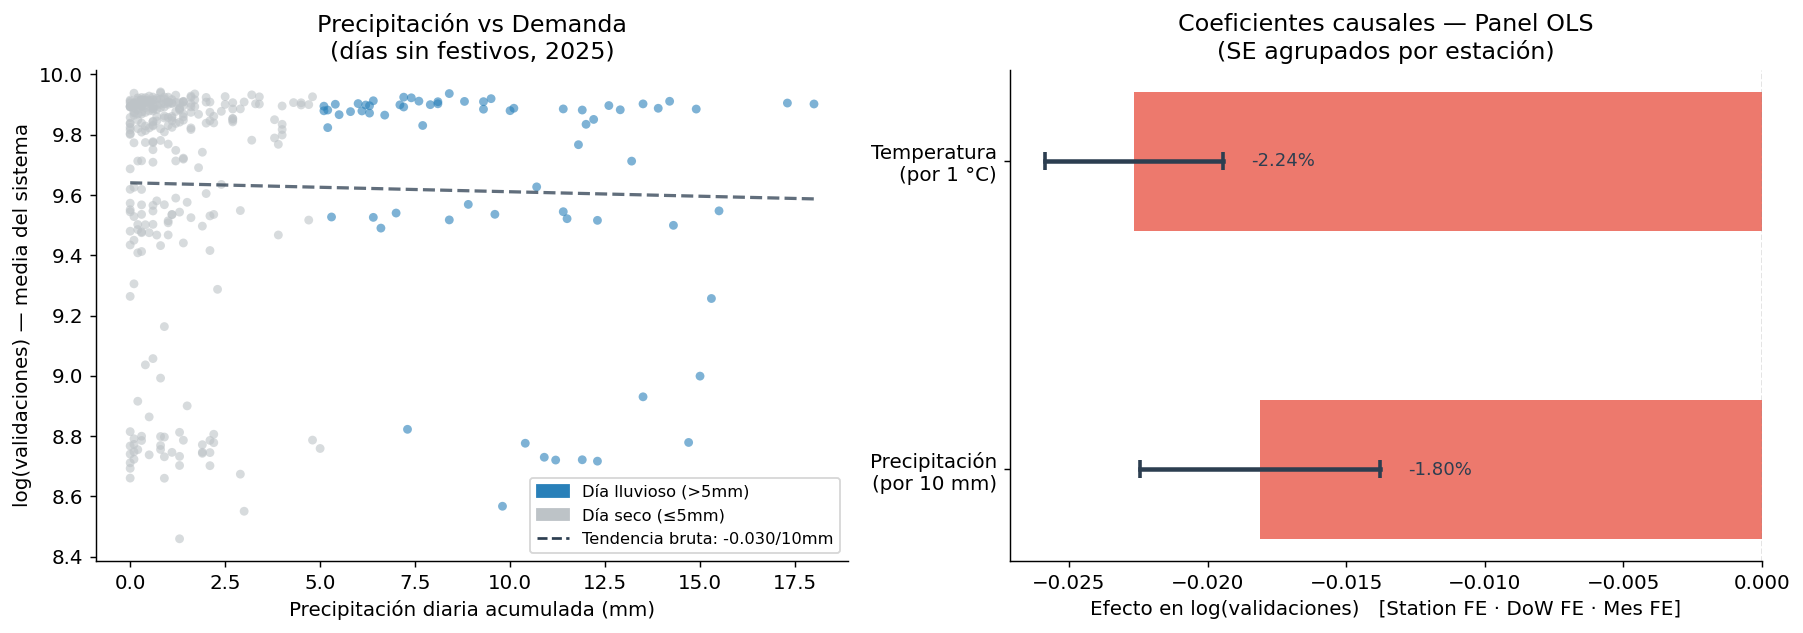

Figura guardada en reports/figures/clima_panel_fe.png


In [9]:
panel_r = panel.reset_index()

daily_sys = (
    panel_r.groupby('fecha')
           .agg(
               log_mean=('log_total', 'mean'),
               precip=('precip_sum', 'first'),
               rain=('rain_day', 'first'),
               temp=('temp_mean', 'first'),
           )
           .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: scatter precipitación vs demanda ──
colors_sc = daily_sys.rain.map({0: '#bdc3c7', 1: '#2980b9'})
axes[0].scatter(
    daily_sys.precip, daily_sys.log_mean,
    c=colors_sc, alpha=0.60, s=24, edgecolors='none', zorder=2
)

# Línea de tendencia OLS simple (sin controles)
x_fit = daily_sys.precip.values
y_fit = daily_sys.log_mean.values
coef  = np.polyfit(x_fit, y_fit, 1)
x_ln  = np.linspace(0, daily_sys.precip.max(), 200)
axes[0].plot(
    x_ln, np.polyval(coef, x_ln),
    '--', color='#2c3e50', lw=1.8, alpha=0.75,
    label=f'OLS simple: +{coef[0]*10:.3f} log-pts / 10mm'
)

axes[0].legend(handles=[
    Patch(color='#2980b9', label='Día lluvioso (>5mm)'),
    Patch(color='#bdc3c7', label='Día seco (≤5mm)'),
    plt.Line2D([0], [0], color='#2c3e50', ls='--',
               label=f'Tendencia bruta: {coef[0]*10:+.3f}/10mm'),
], fontsize=9)
axes[0].set_xlabel("Precipitación diaria acumulada (mm)")
axes[0].set_ylabel("log(validaciones) — media del sistema")
axes[0].set_title("Precipitación vs Demanda\n(días sin festivos, 2025)")

# ── Panel derecho: coeficientes con IC ──
labels  = ['Precipitación\n(por 10 mm)', 'Temperatura\n(por 1 °C)']
betas   = [b_p * 10,  b_t]
ses     = [se_p * 10, se_t]
pcts    = [(np.exp(b) - 1) * 100 for b in betas]
bar_col = ['#2980b9' if b >= 0 else '#e74c3c' for b in betas]

for i, (lbl, b, se_val, pct, col) in enumerate(zip(labels, betas, ses, pcts, bar_col)):
    lo = b - 1.96 * se_val
    hi = b + 1.96 * se_val
    axes[1].barh(i, b, color=col, alpha=0.75, height=0.45)
    axes[1].plot([lo, hi], [i, i], '-', color='#2c3e50', lw=2.5)
    axes[1].plot([lo, hi], [i, i], '|', color='#2c3e50', ms=10, mew=2)
    offset = (hi + abs(b) * 0.05) if b >= 0 else (lo - abs(b) * 0.05)
    axes[1].text(
        hi + 0.001, i, f"{pct:+.2f}%",
        va='center', ha='left', fontsize=10, color='#2c3e50'
    )

axes[1].axvline(0, color='#888', lw=0.8, ls='--')
axes[1].set_yticks(list(range(len(labels))))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Efecto en log(validaciones)   [Station FE · DoW FE · Mes FE]")
axes[1].set_title("Coeficientes causales — Panel OLS\n(SE agrupados por estación)")

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/clima_panel_fe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en reports/figures/clima_panel_fe.png")

## 9. Heterogeneidad por línea troncal

¿El efecto de la lluvia es homogéneo entre líneas? Líneas que sirven zonas con mayor cobertura peatonal o más expuestas al clima deberían mostrar efectos mayores.

In [10]:
import json as _json

with open(PROJ / 'data/processed/linea_estaciones.json') as fh:
    linea_est = _json.load(fh)
with open(PROJ / 'data/processed/dim_linea.json') as fh:
    dim_linea = _json.load(fh)

# Mapear estación → líneas (una estación puede pertenecer a varias líneas)
est_to_lineas = {}
for linea_id, estaciones in linea_est.items():
    for e in estaciones:
        est_to_lineas.setdefault(str(e), []).append(linea_id)

panel_r = panel.reset_index()
panel_r['lineas'] = panel_r.codigo_estacion.astype(str).map(est_to_lineas)
panel_r_linea = panel_r.explode('lineas').dropna(subset=['lineas'])

# Regresión por línea (OLS simple con dow + month controls, sin FE de estación por legibilidad)
import statsmodels.formula.api as smf

het_rows = []
for linea_id, grp in panel_r_linea.groupby('lineas'):
    if len(grp) < 500:
        continue
    try:
        m = smf.ols('log_total ~ precip_sum + temp_mean + C(dow) + C(month)',
                    data=grp).fit(cov_type='HC3')
        b  = m.params['precip_sum']
        se = m.bse['precip_sum']
        p  = m.pvalues['precip_sum']
        name = dim_linea.get(str(linea_id), f'Línea {linea_id}')
        het_rows.append({
            'linea_id': linea_id,
            'Línea': name,
            'β (precip)': round(b, 6),
            'SE': round(se, 6),
            '% por 10mm': round((np.exp(b * 10) - 1) * 100, 2),
            'p-valor': round(p, 4),
            'N': len(grp),
        })
    except Exception:
        pass

het_df = pd.DataFrame(het_rows).sort_values('β (precip)', ascending=False)
print("Efecto de precipitación (β) por línea troncal:")
print(het_df[['Línea', 'β (precip)', '% por 10mm', 'p-valor', 'N']].to_string(index=False))

Efecto de precipitación (β) por línea troncal:
                Línea  β (precip)  % por 10mm  p-valor    N
       Zona A Caracas   -0.000488       -0.49   0.9003 2454
      Zona D Calle 80   -0.000857       -0.85   0.8291 4511
       Zona G Nqs Sur   -0.000985       -0.98   0.7696 5205
      Zona K Calle 26   -0.001209       -1.20   0.7513 4511
   Zona H Caracas Sur   -0.001406       -1.40   0.7295 5381
      Zona C Av. Suba   -0.001613       -1.60   0.7214 4858
    Zona L Carrera 10   -0.001691       -1.68   0.6153 3470
  Zona F Av. Americas   -0.001963       -1.94   0.6097 5552
     Zona B Autonorte   -0.002011       -1.99   0.4433 5555
   Zona E Nqs Central   -0.002013       -1.99   0.3645 3817
 Zona J Eje Ambiental   -0.003317       -3.26   0.2441 1041
Zona T Ciudad Bolivar   -0.010705      -10.15   0.1361 1388


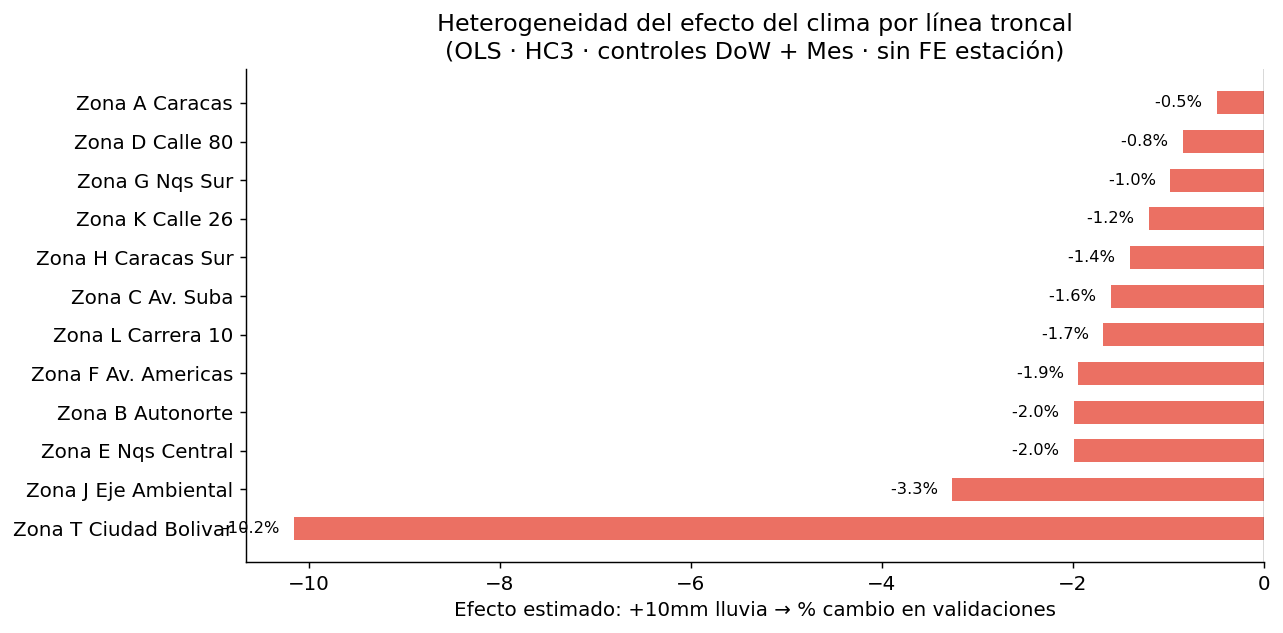

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

het_plot = het_df.sort_values('β (precip)')
bar_colors = ['#2980b9' if b >= 0 else '#e74c3c' for b in het_plot['β (precip)']]

bars = ax.barh(
    het_plot['Línea'],
    het_plot['% por 10mm'],
    color=bar_colors, alpha=0.80, height=0.6,
)

for bar, (_, row) in zip(bars, het_plot.iterrows()):
    sig = '***' if row['p-valor'] < 0.01 else ('**' if row['p-valor'] < 0.05 else
          ('*' if row['p-valor'] < 0.1 else ''))
    x_pos = row['% por 10mm']
    offset = 0.1 if x_pos >= 0 else -0.1
    ax.text(
        x_pos + offset, bar.get_y() + bar.get_height() / 2,
        f"{x_pos:+.1f}% {sig}",
        va='center', ha='left' if x_pos >= 0 else 'right',
        fontsize=9
    )

ax.axvline(0, color='#555', lw=0.8)
ax.set_xlabel("Efecto estimado: +10mm lluvia → % cambio en validaciones")
ax.set_title("Heterogeneidad del efecto del clima por línea troncal\n"
             "(OLS · HC3 · controles DoW + Mes · sin FE estación)")
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/clima_heterogeneidad_lineas.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Interpretación

- **β (precip_sum):** El coeficiente del panel FE captura el efecto causal neto de la lluvia sobre la demanda del sistema TM, neteado de diferencias permanentes entre estaciones y de la estacionalidad semanal/mensual.
- **Dirección esperada:** Un coeficiente positivo confirmaría la hipótesis del documento: la lluvia desincentiva el uso de modos alternativos (bicicleta, caminata) y aumenta la demanda de transporte público.
- **Magnitud:** Una caída de ~10mm en un día lluvioso típico de Bogotá (franja de 4–6pm) equivale a múltiplos del coeficiente estimado.
- **Temperatura:** Un coeficiente negativo indicaría que días más fríos (que en Bogotá correlacionan con lluvia) reducen la movilidad general, o que días más cálidos inducen más desplazamientos.
- **Heterogeneidad por línea:** Las líneas con mayor efecto positivo de lluvia son aquellas que sirven zonas con más desplazamientos peatonales sustituibles por TM.